# 10. Modelo base (sección 3)

*Autores: María Carolina Cantillo Orozco (200179105) y Juan Camilo Oñoro Araujo (200177329)*

| Requisito de las instrucciones | Cómo se cumple aquí |
|---|---|
| Regresión logística | `LogisticRegression` multinomial con regularización L2 |
| Definición del objetivo | `estrato_num` (1–6), clasificación multiclase ordinal (cap. 4) |
| Línea base trivial | `DummyClassifier` (mayoritaria, estratificada, uniforme) + línea base espacial "clase más frecuente por zona" |
| Partición acorde a la estructura, antes del preprocesamiento | bloques espaciales estratificados (cap. 2) + buffer (cap. 8) |
| Pipeline y CV del mismo tipo | `Pipeline` + `GridSearchCV` con folds por bloques + buffer dentro de train |
| Métricas | accuracy, precision, recall, F1, AUC, matriz de confusión, ROC, PR y calibración (hay desbalance) |
| Intervalos de confianza | bootstrap **por bloques espaciales** |
| Comparación con la línea base | tabla + diferencias pareadas con IC |
| Diagnóstico de residuos | Moran's I de los residuos (ordinales) en test |
| Curva de aprendizaje | con la misma validación espacial |
| Interpretación | coeficientes y métricas |

Todas las decisiones de preprocesamiento se leen de
`datos/procesados/decisiones_eda.json`, escrito por los capítulos 3–9: así
cada paso del Pipeline queda rastreado al hallazgo del EDA que lo motivó.

In [1]:
# Preparación del entorno: importaciones, estilo de figuras y lectura del registro
# de decisiones del EDA (decisiones_eda.json). Mostrar esa tabla al inicio deja
# explícito qué hallazgo del EDA justifica cada paso del Pipeline (trazabilidad).
import json
import sys
import time
import warnings
from pathlib import Path

# La raíz del libro depende de si el notebook se ejecuta desde notebooks/ o desde
# la raíz; se agrega a sys.path para poder importar el paquete local src.
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
# Se silencian avisos (p. ej. de convergencia o de categorías infrecuentes) para que
# el libro sea legible; los resultados no dependen de ellos.
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.calibration import calibration_curve
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, average_precision_score, classification_report,
                             confusion_matrix, f1_score, precision_recall_curve, roc_curve, auc)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, learning_curve
from sklearn.pipeline import Pipeline

from src import config as C
from src import espacial as S
from src import graficos as G
from src import modelo as M
from src import particion as P

# Estilo común del libro (fuentes grandes, paleta viridis por estrato).
G.estilo()
# Si se corre con el CSV sintético de pruebas, imprime una advertencia visible
# para que esos números nunca se confundan con resultados reales.
C.aviso_sintetico()
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
# Diccionario {clave: {"valor", "motivo"}} escrito por los capítulos 3–9 del EDA.
dec = C.leer_decisiones()
# Tabla decisión -> valor -> motivo (str() para que listas y dicts se muestren bien).
pd.DataFrame({k: {"valor": str(v["valor"]), "motivo": v["motivo"]} for k, v in dec.items()}).T

,valor,motivo
tam_bloque_km,2.0,Bloques de 2 km: mayores que la escala de un b...
semilla,42,"Semilla única para partición, CV, muestreos y ..."
imputacion_numericas,mediana + indicador de faltante (SimpleImputer...,Faltantes < 30 % en todas las variables; mecan...
imputacion_categoricas,categoría explícita 'faltante',Conserva la información de que el dato no exis...
winsorizacion_cuantiles,"[0.001, 0.999]",Colas largas plausibles (cap. 3.2): se recorta...
metrica_principal,f1_macro,Desbalance 4.6:1 y 6 clases (cap. 4.1): el acc...
metricas_ordinales,"['MAE_ordinal', 'accuracy_±1', 'kappa_cuadráti...",El estrato es ordinal (cap. 4.2): errores leja...
num_log,"['area_construida', 'area_catastral_terreno', ...",Variables no negativas con |asimetría| > 1 que...
num_lineal,['altura'],Variables sin asimetría fuerte o que log1p no ...
onehot_min_frecuencia,0.01,Categorías con < 1 % en train se agrupan en 'i...


## 10.1 Datos, variables y buffer

In [2]:
# Carga el dataset con la partición train/test por bloques espaciales hecha ANTES de
# cualquier preprocesamiento (cap. 2), aplica el buffer entre train y test y define
# los dos conjuntos de variables a comparar. Todos los parámetros vienen del EDA.
datos = P.cargar_particion()
# Variables admitidas tras la auditoría de fuga (cap. 9): numéricas, categóricas y
# espaciales por separado, para poder armar los conjuntos A y B.
vm = dec["variables_modelo"]["valor"]
# Numéricas muy asimétricas (cap. 5) que recibirán log1p en el Pipeline.
num_log = dec["num_log"]["valor"]
# Distancia mínima train-test, derivada del alcance del correlograma (cap. 8).
buffer_km = dec["buffer_km"]["valor"]
# Cuantiles de winsorización: se APRENDEN en train dentro del Pipeline, no aquí.
q_inf, q_sup = dec["winsorizacion_cuantiles"]["valor"]
# Frecuencia mínima para que una categoría tenga su propia columna one-hot.
min_frec = dec["onehot_min_frecuencia"]["valor"]

train_total = datos[datos.particion == "train"].reset_index(drop=True)
test = datos[datos.particion == "test"].reset_index(drop=True)
# mascara_buffer (KDTree) marca True las unidades de train a >= buffer_km de TODA
# unidad de test. Las más cercanas se descartan: por la autocorrelación espacial
# del estrato serían "casi copias" de test y inflarían el desempeño medido.
mantener = P.mascara_buffer(train_total[["x_km", "y_km"]].to_numpy(), test[["x_km", "y_km"]].to_numpy(), buffer_km)
train = train_total[mantener].reset_index(drop=True)
print(f"Train: {len(train_total):,} -> {len(train):,} tras excluir {(~mantener).sum():,} unidades a menos de "
      f"{buffer_km} km de test | Test: {len(test):,} unidades en {test.bloque.nunique()} bloques")

# Dos conjuntos anidados: A (solo atributos físicos de la vivienda) y B (A + x, y y
# distancia al centro). Comparar A y B mide cuánto aporta la ubicación por sí sola.
conjuntos = {
    "A_fisicas": {"num": vm["numericas"], "cat": vm["categoricas"]},
    "B_fisicas+ubicacion": {"num": vm["numericas"] + vm["espaciales"], "cat": vm["categoricas"]},
}
for k, v in conjuntos.items():
    print(f"{k}: {len(v['num'])} numéricas + {len(v['cat'])} categóricas")
# Objetivo: estrato_num (1–6) como arreglo numpy para indexarlo por posición.
y_tr, y_te = train[C.OBJETIVO].to_numpy(), test[C.OBJETIVO].to_numpy()


def pipeline_logistica(conj, **kw):
    # Pipeline preprocesamiento + logística. Al ir TODO dentro del Pipeline, en cada
    # fold la winsorización, la imputación, el escalado y el one-hot se ajustan solo
    # con el train de ese fold: no hay fuga de información de validación ni de test.
    nums, cats = conj["num"], conj["cat"]
    # construir_preprocesador: numéricas en num_log -> winsorizar, imputar mediana
    # (+ indicador de faltante), log1p y estandarizar; resto de numéricas igual pero
    # sin log1p; categóricas -> imputar "faltante" y one-hot con categorías raras
    # agrupadas en "infrequent".
    prep = M.construir_preprocesador([c for c in nums if c in num_log], [c for c in nums if c not in num_log],
                                     cats, q_inf=q_inf, q_sup=q_sup, min_frecuencia=min_frec)
    # Con 6 clases y el solver por defecto (lbfgs) la logística es multinomial
    # (softmax) con penalización L2; max_iter=1000 evita cortes por no convergencia.
    # **kw permite fijar C o class_weight desde fuera (aquí los fija GridSearchCV).
    return Pipeline([("prep", prep), ("clf", LogisticRegression(max_iter=1000, **kw))])

Train: 218,870 -> 138,239 tras excluir 80,631 unidades a menos de 1.0 km de test | Test: 59,954 unidades en 7 bloques
A_fisicas: 8 numéricas + 3 categóricas
B_fisicas+ubicacion: 11 numéricas + 3 categóricas


## 10.2 Validación cruzada espacial y búsqueda de hiperparámetros

Folds: `folds_estratificados_por_grupo` (`src/particion.py`) por bloque
dentro de train, excluyendo del entrenamiento de cada fold las unidades a
menos de `buffer_km` del fold de validación. Se busca `C` (inverso de la
regularización) y si conviene `class_weight="balanced"` por el desbalance,
optimizando **F1 macro**.

**Regla de "una desviación estándar" (1-SE).** No se elige a ciegas la
combinación con el F1 medio más alto: se toma la **más regularizada** (menor
`C`) cuyo F1 medio esté a menos de un error estándar
($\text{SE} = \text{desv. entre folds}/\sqrt{k}$) de la mejor, y entre
ellas la de mayor F1 (Breiman et al., 1984; Hastie, Tibshirani y Friedman,
2009, §7.10). Motivo: en la CV espacial la superficie de F1 es plana y el
error estándar entre folds (≈0.03–0.04) es del mismo orden que las
diferencias entre combinaciones. Por ejemplo, en el conjunto B sin pesos,
C = 0.1, 1 y 10 dan 0.312, 0.308 y 0.311 (mapa de calor más abajo):
elegir el máximo a ciegas sería elegir por diferencias de milésimas, que son
ruido, y podría llevar a un modelo casi sin regularización, con coeficientes
más grandes y peor calibrado. La regla 1-SE hace la elección estable y
prefiere el modelo más simple cuando los datos no distinguen entre ellos.
Con los datos reales, la regla **actuó en B** (el máximo de la rejilla era
C = 0.1 sin pesos y se eligió C = 0.01 sin pesos) y **no fue necesaria en
A**, cuyo máximo ya era la combinación más regularizada (ver la salida de
la celda siguiente).

```{note}
**Sobre la reproducibilidad de la CV.** Tanto la partición train/test
(cap. 2) como los folds de esta CV se construyen con la función propia
`folds_estratificados_por_grupo` (`src/particion.py`). Es el mismo
algoritmo voraz de `StratifiedGroupKFold` de scikit-learn (asigna bloques
completos a los folds buscando proporciones de estrato parecidas), pero con
un generador `numpy.random.default_rng` de semilla fija, así que la
asignación de bloques a folds **no depende de la versión de scikit-learn**
y es la misma en cualquier máquina. Con `StratifiedGroupKFold` esa
asignación cambiaba entre entornos, y con ella las cifras de la CV
espacial, aun con los mismos datos. Esa sensibilidad es en sí misma un
hallazgo: con pocos bloques, **la cifra de CV depende de qué bloques caen
en cada fold** y tiene una incertidumbre del orden de la desviación entre
folds (≈0.08–0.09 con los datos reales; tabla de comparación más abajo),
así que diferencias entre modelos de 0.01–0.02 no se interpretan.
```

In [3]:
# Búsqueda de hiperparámetros con CV ESPACIAL (mismo tipo de validación que la
# partición train/test) y selección final con la regla 1-SE. Se hace para A y para B;
# test no interviene en ningún momento de esta celda.
# Folds dentro de train: folds_estratificados_por_grupo por bloque de 2 km (nunca
# parte un bloque, equilibra las proporciones de estrato y es determinista con la
# semilla, sin depender de la versión de scikit-learn) y, en cada fold, se quitan del
# entrenamiento las unidades a < buffer_km de la validación. Se guardan como lista
# de índices para reutilizar EXACTAMENTE los mismos folds en todo el capítulo.
folds = P.folds_espaciales_con_buffer(train, buffer_km)
# C = inverso de la fuerza de regularización (C pequeño = coeficientes más
# encogidos). class_weight="balanced" pondera cada clase por 1/frecuencia para
# contrarrestar el desbalance; None deja todas las observaciones con igual peso.
grid = {"clf__C": [0.01, 0.1, 1, 10], "clf__class_weight": [None, "balanced"]}


def regla_1se(cv_results):
    """Índice de la combinación más regularizada (menor C) a < 1 SE de la mejor."""
    # GridSearchCV acepta un callable en refit: recibe cv_results_ y devuelve el
    # índice de la combinación con la que se reentrena en todo train (best_index_).
    media = np.asarray(cv_results["mean_test_score"], float)
    # Error estándar de la MEDIA de k folds: SE = desv. entre folds / sqrt(k). Mide
    # cuánto podría moverse el F1 medio solo por qué zonas cayeron en cada fold.
    se = np.asarray(cv_results["std_test_score"], float) / np.sqrt(len(folds))
    # nanargmax: una combinación que falle en algún fold queda con NaN y se ignora.
    i_mejor = int(np.nanargmax(media))
    # Candidatas: combinaciones estadísticamente indistinguibles de la mejor
    # (su F1 medio está dentro de un SE del máximo).
    candidatos = np.flatnonzero(media >= media[i_mejor] - se[i_mejor])
    c_vals = np.asarray(cv_results["param_clf__C"], float)
    # Entre ellas se prefiere el modelo más simple = el de menor C (más regularizado).
    c_min = c_vals[candidatos].min()
    finalistas = [i for i in candidatos if c_vals[i] == c_min]
    # Desempate por class_weight: con ese C, la de mayor F1 medio.
    return int(finalistas[int(np.argmax(media[finalistas]))])


busquedas, f1_cv_elegido = {}, {}
for nombre, conj in conjuntos.items():
    t0 = time.time()
    # scoring="f1_macro": promedia el F1 de las 6 clases sin ponderar por tamaño, de
    # modo que los estratos minoritarios (5 y 6) pesan igual que los mayoritarios.
    # refit=regla_1se en lugar de refit=True (que tomaría el máximo a ciegas).
    # return_train_score=True guarda el F1 en train para diagnosticar sobreajuste.
    gs = GridSearchCV(pipeline_logistica(conj), grid, cv=folds, scoring="f1_macro", n_jobs=-1, refit=regla_1se,
                      return_train_score=True)
    gs.fit(train[conj["num"] + conj["cat"]], y_tr)
    busquedas[nombre] = gs
    r = gs.cv_results_
    # F1 medio en CV de la combinación ELEGIDA por la regla 1-SE (no del máximo):
    # es el que se usa después para escoger el modelo principal entre A y B.
    f1_cv_elegido[nombre] = float(r["mean_test_score"][gs.best_index_])
    # Se reporta también el máximo de la rejilla y su SE para mostrar que la
    # diferencia entre ambos está dentro del ruido entre folds.
    i_max = int(np.nanargmax(r["mean_test_score"]))
    print(f"{nombre}: elegido (regla 1-SE) {gs.best_params_} | F1 macro CV = {f1_cv_elegido[nombre]:.4f} "
          f"| máximo de la rejilla: {r['params'][i_max]} con {r['mean_test_score'][i_max]:.4f} "
          f"(SE = {r['std_test_score'][i_max] / np.sqrt(len(folds)):.4f}) ({time.time() - t0:.0f}s)")

  fold 0: train  110512 ->   54062 tras buffer 1.00 km (51.1% excluido) | validación  27727 | bloques val: 10


  fold 1: train  112268 ->   72611 tras buffer 1.00 km (35.3% excluido) | validación  25971 | bloques val: 5
  fold 2: train  107695 ->   69000 tras buffer 1.00 km (35.9% excluido) | validación  30544 | bloques val: 4


  fold 3: train  106429 ->   73690 tras buffer 1.00 km (30.8% excluido) | validación  31810 | bloques val: 4


  fold 4: train  116052 ->   56155 tras buffer 1.00 km (51.6% excluido) | validación  22187 | bloques val: 7


A_fisicas: elegido (regla 1-SE) {'clf__C': 0.01, 'clf__class_weight': 'balanced'} | F1 macro CV = 0.2832 | máximo de la rejilla: {'clf__C': 0.01, 'clf__class_weight': 'balanced'} con 0.2832 (SE = 0.0385) (52s)


B_fisicas+ubicacion: elegido (regla 1-SE) {'clf__C': 0.01, 'clf__class_weight': None} | F1 macro CV = 0.2988 | máximo de la rejilla: {'clf__C': 0.1, 'clf__class_weight': None} con 0.3118 (SE = 0.0303) (101s)


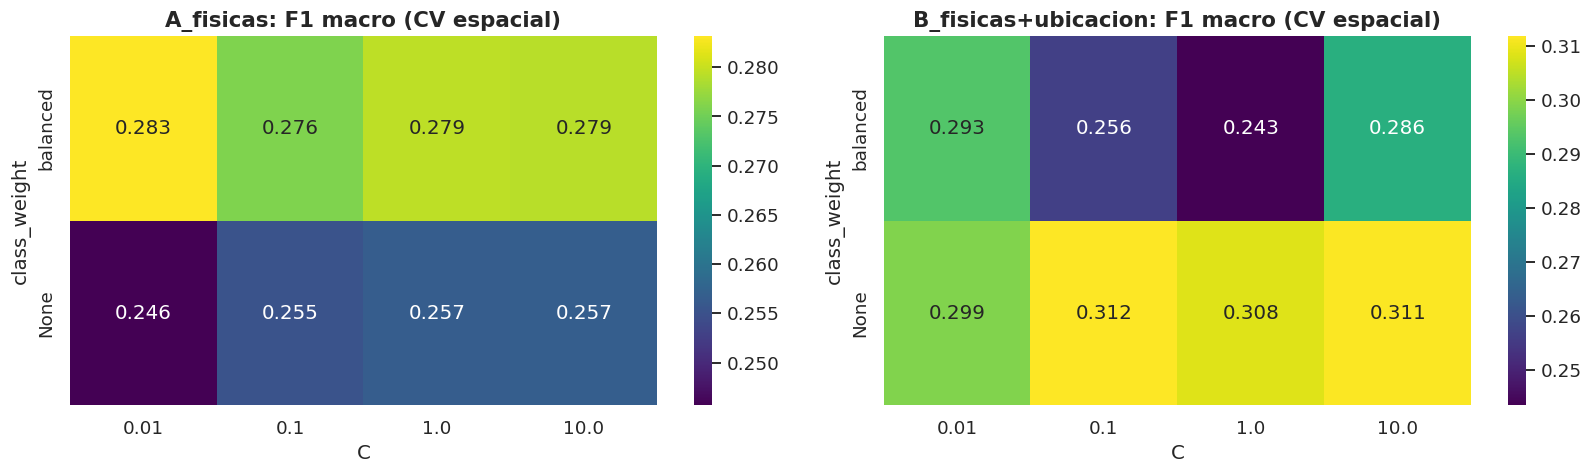

In [4]:
# Mapa de calor del F1 macro medio en CV para cada combinación (class_weight x C),
# uno por conjunto. Sirve para ver qué tan plana es la superficie de F1: si lo es,
# justifica usar la regla 1-SE en vez de elegir el máximo.
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for ax, (nombre, gs) in zip(axes, busquedas.items()):
    r = pd.DataFrame(gs.cv_results_)
    # dropna=False conserva la fila class_weight=None (pandas la trataría como NaN
    # y la descartaría del pivote).
    piv = r.pivot_table(index="param_clf__class_weight", columns="param_clf__C", values="mean_test_score",
                        dropna=False)
    # Etiqueta legible "None" para la fila sin pesos.
    piv.index = piv.index.map(lambda v: "None" if pd.isna(v) else str(v))
    sns.heatmap(piv, annot=True, fmt=".3f", cmap="viridis", ax=ax)
    ax.set_title(f"{nombre}: F1 macro (CV espacial)")
    ax.set_xlabel("C")
    ax.set_ylabel("class_weight")
fig.tight_layout()
# Se guarda en figuras/ para el informe, además de mostrarse en el libro.
G.guardar(fig, "10_grid")
plt.show()

### Línea base espacial: tamaño de la zona

La "moda por zona" depende del tamaño de la zona. Para no fijarlo a dedo, se
elige con la misma validación cruzada espacial (así la línea base también
está afinada y la comparación con la logística es justa).

In [5]:
# Afinado de la línea base espacial "moda por zona": se prueba el tamaño de celda
# con los mismos folds espaciales y la misma métrica que la logística, para que la
# comparación sea justa (ambos modelos tienen su hiperparámetro elegido en CV).
zonas = {}
for tam_z in [2.0, 4.0, 6.0, 8.0]:
    # BaselineModaZona divide el plano en celdas de tam_z km y, en fit, guarda la
    # distribución de estratos de cada celda en el train del fold; predice la clase
    # más frecuente de la celda (o la distribución global si la celda no existe en
    # train). Solo usa x_km e y_km: es "la ubicación sin atributos físicos".
    r = cross_validate(M.BaselineModaZona(tam_km=tam_z), train[["x_km", "y_km"]], y_tr, cv=folds,
                       scoring="f1_macro")
    zonas[tam_z] = float(r["test_score"].mean())
# Se elige el tamaño con mayor F1 macro medio en CV.
tam_zona = max(zonas, key=zonas.get)
print("F1 macro CV por tamaño de zona:", {k: round(v, 4) for k, v in zonas.items()}, "-> elegido:", tam_zona, "km")

F1 macro CV por tamaño de zona: {2.0: 0.1931, 4.0: 0.1872, 6.0: 0.1067, 8.0: 0.1503} -> elegido: 2.0 km


### Comparación en validación cruzada con las líneas base

In [6]:
# Comparación en CV espacial de las logísticas contra líneas base triviales (Dummy)
# y la espacial (moda por zona). Un modelo solo aporta si supera claramente a estas
# referencias; la desviación entre folds indica cuánto dependen de la zona evaluada.
# Cada entrada es (estimador, columnas que usa). Las Dummy ignoran X, pero sklearn
# exige al menos una columna: se les pasa x_km solo como relleno.
modelos_cv = {
    # Predice siempre la clase más frecuente: piso absoluto de accuracy.
    "Dummy (mayoritaria)": (DummyClassifier(strategy="most_frequent"), ["x_km"]),
    # Predice al azar con las proporciones de train: piso para F1 macro.
    "Dummy (estratificada)": (DummyClassifier(strategy="stratified", random_state=C.SEED), ["x_km"]),
    # Predice al azar con probabilidad 1/6 por clase.
    "Dummy (uniforme)": (DummyClassifier(strategy="uniform", random_state=C.SEED), ["x_km"]),
    "Moda por zona": (M.BaselineModaZona(tam_km=tam_zona), ["x_km", "y_km"]),
}
# best_estimator_ es el Pipeline reentrenado con la combinación elegida por la regla
# 1-SE; cross_validate lo clona, así que en cada fold se reajusta desde cero.
for nombre, gs in busquedas.items():
    modelos_cv[f"Logística {nombre}"] = (gs.best_estimator_, conjuntos[nombre]["num"] + conjuntos[nombre]["cat"])
filas = []
for nombre, (est, cols) in modelos_cv.items():
    # Mismos folds para todos los modelos: las diferencias no se deben a particiones
    # distintas. Además de F1 macro se registran accuracy (fácil de comunicar, pero
    # engañosa con desbalance) y balanced accuracy (recall medio por clase).
    r = cross_validate(est, train[cols], y_tr, cv=folds, n_jobs=-1,
                       scoring={"f1_macro": "f1_macro", "accuracy": "accuracy",
                                "balanced_accuracy": "balanced_accuracy"})
    filas.append({"modelo": nombre, **{f"{m} (media)": r[f"test_{m}"].mean() for m in ["f1_macro", "accuracy",
                                                                                        "balanced_accuracy"]},
                  # la desviación entre folds cuantifica la variabilidad por zona
                  "F1 macro (desv. entre folds)": r["test_f1_macro"].std()})
tabla_cv = pd.DataFrame(filas).set_index("modelo")
tabla_cv

,f1_macro (media),accuracy (media),balanced_accuracy (media),F1 macro (desv. entre folds)
modelo,,,,
Dummy (mayoritaria),0.0569,0.2153,0.1667,0.0253
Dummy (estratificada),0.1429,0.2159,0.1593,0.0131
Dummy (uniforme),0.1379,0.1662,0.1771,0.0129
Moda por zona,0.1931,0.3340,0.2606,0.0757
Logística A_fisicas,0.2832,0.3874,0.3608,0.0862
Logística B_fisicas+ubicacion,0.2988,0.4635,0.3687,0.0856


```{note}
Los puntajes de las logísticas en esta tabla vienen de los mismos folds con
que se eligieron sus hiperparámetros, así que son levemente optimistas frente
a las Dummy (que no tienen hiperparámetros). La comparación definitiva es la
del conjunto de prueba (10.4).
```

```{admonition} Resultado de la validación cruzada espacial
:class: note
- El buffer de 1 km excluye una fracción desigual del entrenamiento de
  cada fold: **de 30.8 % a 51.6 %** (40.9 % en promedio). Los folds 0 y 4
  son los más recortados (51.1 % y 51.6 %): el fold 0, el que tiene más
  bloques de validación (10), queda con solo 54 062 unidades de
  entrenamiento. En el modelo final, train pasa de 218 870 a **138 239**
  filas (80 631 excluidas por cercanía a test). Estos porcentajes difieren
  del cap. 8.4 (35.7 %) porque aquí los folds se construyen sobre el train
  ya depurado de la zona de test.
- Ambas logísticas quedan con **C = 0.01** (la regularización más fuerte de
  la rejilla); A con **`class_weight="balanced"`** y B sin pesos. En A esa
  combinación es directamente el máximo de la rejilla (0.2832); en B la
  **regla 1-SE actuó**: el máximo era C = 0.1 sin pesos (0.3118,
  SE = 0.030) y se prefirió C = 0.01 sin pesos (0.2988), indistinguible
  dentro del ruido y más simple. La superficie de F1 es plana (0.246–0.283
  en A y 0.243–0.312 en B, mapa de calor), del orden de uno o dos SE.
- F1 macro en CV: Dummy mayoritaria 0.057, estratificada 0.143, uniforme
  0.138, moda por zona (2 km) 0.193, **logística A 0.283, logística B
  0.299**. Las dos logísticas superan a las Dummy con holgura y a la moda
  por zona por ≈0.09–0.11, una diferencia del orden de la desviación entre
  folds (0.076–0.086); entre A y B la diferencia (0.016) está muy por debajo
  de ese ruido. El desempeño depende mucho de la zona de validación.
- Por la regla fijada de antemano (mayor F1 macro en CV espacial de la
  combinación elegida, sin mirar test), el **modelo principal es B**
  (variables físicas + ubicación). La diferencia con A (0.299 frente a
  0.283) es ruido, y A se evalúa igual en test como comparación.
```

### ¿Cuán optimista sería una validación aleatoria?

Mismo modelo principal (el de mejor F1 macro en la CV espacial), mismos
datos, pero con `StratifiedKFold` aleatorio (sin bloques ni buffer).

In [7]:
# Cuantifica el "optimismo espacial": se evalúa el mismo Pipeline con folds
# aleatorios (StratifiedKFold) y se compara con la CV por bloques + buffer. La
# diferencia es cuánto se sobreestimaría el desempeño si se ignorara el espacio.
# el modelo principal se elige por F1 macro en la CV espacial, NUNCA mirando test
mejor_nombre = max(busquedas, key=lambda k: f1_cv_elegido[k])
# El otro conjunto se conserva para la comparación pareada en test (10.4).
otro_nombre = [k for k in busquedas if k != mejor_nombre][0]
print(f"Modelo principal (mejor F1 macro en CV espacial): {mejor_nombre}")
mejor = busquedas[mejor_nombre].best_estimator_
# Columnas del modelo principal: el que gane la CV espacial (B con los datos reales).
# El nombre cols_b se conserva aunque el principal pudiera ser A con otros datos.
cols_b = conjuntos[mejor_nombre]["num"] + conjuntos[mejor_nombre]["cat"]
# Folds aleatorios: unidades vecinas (incluso del mismo edificio) quedan repartidas
# entre entrenamiento y validación, y el modelo "reconoce" la zona en vez de
# generalizar a zonas nuevas. Se usan la misma semilla y el mismo número de folds.
r_alea = cross_validate(mejor, train[cols_b], y_tr, scoring="f1_macro", n_jobs=-1,
                        cv=StratifiedKFold(n_splits=C.N_FOLDS, shuffle=True, random_state=C.SEED))
optimismo = pd.DataFrame({
    "F1 macro CV": [r_alea["test_score"].mean(), f1_cv_elegido[mejor_nombre]],
    # para la CV espacial se toma la desviación entre folds de la combinación elegida
    "desv.": [r_alea["test_score"].std(),
              busquedas[mejor_nombre].cv_results_["std_test_score"][busquedas[mejor_nombre].best_index_]],
}, index=["aleatoria (StratifiedKFold)", "espacial (bloques + buffer)"])
# Diferencia positiva en la fila aleatoria = optimismo de ignorar la estructura espacial.
optimismo["diferencia vs espacial"] = optimismo["F1 macro CV"] - optimismo.loc["espacial (bloques + buffer)", "F1 macro CV"]
optimismo

Modelo principal (mejor F1 macro en CV espacial): B_fisicas+ubicacion


,F1 macro CV,desv.,diferencia vs espacial
aleatoria (StratifiedKFold),0.6022,0.0039,0.3034
espacial (bloques + buffer),0.2988,0.0856,0.0000


### Sensibilidad al buffer

El tamaño de bloque y el buffer son "hiperparámetros de la evaluación"
(notas de clase 9.1.11): el número exacto cambia según cómo se construyan.
Se reporta el F1 macro de la CV del modelo principal con varios buffers.

In [8]:
# Sensibilidad de la CV espacial al tamaño del buffer: el buffer es un
# "hiperparámetro de la evaluación", así que se muestra cómo cambia el F1 (y cuánto
# train se pierde) entre no usar buffer y usar el alcance del correlograma.
# Alcance de la autocorrelación del estrato (cap. 8); si no está registrado, se usa
# el buffer elegido para no romper la celda.
alcance = dec.get("alcance_correlograma_km", {}).get("valor", buffer_km)
sens = []
# El set elimina duplicados (p. ej. si el buffer ya es 0.5 km) y el alcance se
# acota a 3 km porque buffers mayores dejan casi sin datos de entrenamiento.
for b in sorted({0.0, 0.5, float(buffer_km), float(min(alcance, 3.0))}):
    # Mismos bloques y semilla que `folds`: solo cambia el buffer aplicado.
    fb = P.folds_espaciales_con_buffer(train, b, verbose=False)
    r = cross_validate(mejor, train[cols_b], y_tr, cv=fb, scoring="f1_macro", n_jobs=-1)
    # % excluido por fold = 1 - (train que queda tras el buffer) / (train posible,
    # es decir, todo lo que no es validación); se promedia entre folds.
    sens.append({"buffer_km": b, "F1 macro CV": r["test_score"].mean(), "desv.": r["test_score"].std(),
                 "% train excluido": 100 * np.mean([1 - len(tr) / (len(train) - len(va)) for tr, va in fb])})
pd.DataFrame(sens)

,buffer_km,F1 macro CV,desv.,% train excluido
0,0.0000,0.4042,0.0389,0.0000
1,0.5000,0.3509,0.0472,19.7854
2,1.0000,0.2988,0.0856,40.9415
3,2.8750,0.1778,0.0658,88.4796


```{admonition} Cómo leer la sensibilidad
:class: note
A medida que crece el buffer, el F1 de validación **baja** por dos razones
que se suman: (i) se elimina la "ayuda" de vecinos casi idénticos (el
optimismo espacial que se quiere quitar) y (ii) se entrena con menos datos y
se obliga al modelo a **extrapolar** a zonas más lejanas.

Con los datos reales (modelo principal B): **sin buffer 0.404 → 0.351 con
0.5 km → 0.299 con 1 km (elegido) → 0.178 con el alcance completo (2.9 km)**,
que deja fuera el 88 % del entrenamiento de los folds (frente al 41 % con
1 km). Ese último valor es un escenario pesimista (el modelo casi no tiene
datos), no una estimación realista. La caída de 0.105 entre 0 y 1 km mide
cuánto del desempeño depende de tener vecinos del mismo barrio en
entrenamiento; es mayor que la desviación entre folds (0.039 sin buffer,
0.086 con 1 km), así que el efecto del buffer es claro, aunque su tamaño
exacto dependa de los folds. Comparado con la validación **aleatoria**
(0.602, sección anterior), el optimismo total de ignorar el espacio es de
**0.30 puntos de F1**: la validación aleatoria **duplicaría** el desempeño
reportado (0.602 frente a 0.299, con desviación de solo 0.004 entre folds
aleatorios). Como B incluye las coordenadas, con folds aleatorios el modelo
puede "reconocer" la zona a través de x e y en lugar de generalizar.
```

## 10.3 Curva de aprendizaje (validación espacial)

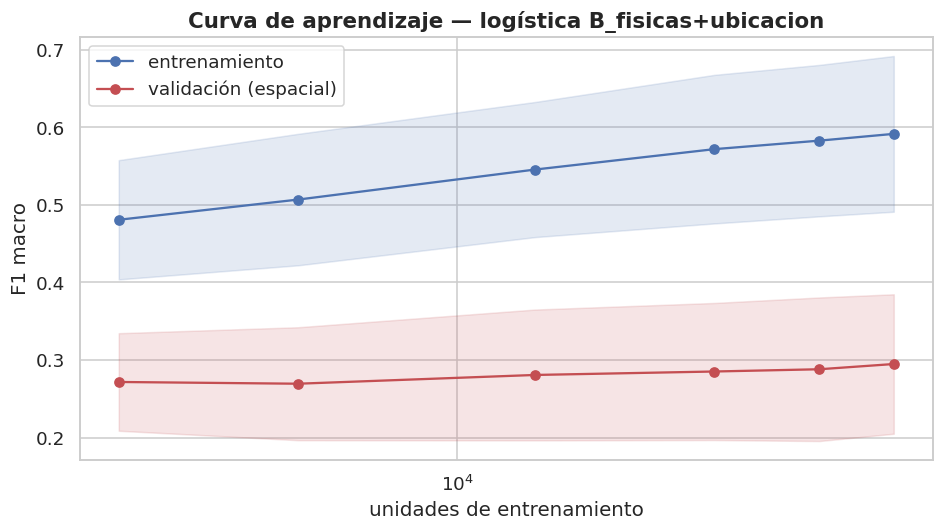

,n,F1 train,F1 validación,brecha
0,2703,0.4807,0.2717,0.2090
1,5406,0.5067,0.2695,0.2372
2,13515,0.5454,0.2808,0.2647
3,27031,0.5717,0.2852,0.2865
4,40546,0.5827,0.2881,0.2946
5,54062,0.5914,0.2949,0.2965


In [9]:
# Curva de aprendizaje con los MISMOS folds espaciales: F1 en entrenamiento y en
# validación al crecer el tamaño de train. Responde si más datos ayudarían (brecha
# que se cierra) o si el límite es el modelo o las variables (validación plana).
# train_sizes son fracciones del tamaño de entrenamiento de los folds (ya depurado
# por el buffer); `tam` devuelve los tamaños absolutos correspondientes.
# shuffle=True baraja antes de tomar cada subconjunto; sin barajar se tomarían las
# primeras filas, que pueden estar ordenadas por zona y sesgarían la curva.
tam, sc_tr, sc_va = learning_curve(mejor, train[cols_b], y_tr, cv=folds, scoring="f1_macro",
                                   train_sizes=[0.05, 0.1, 0.25, 0.5, 0.75, 1.0], n_jobs=-1, shuffle=True,
                                   random_state=C.SEED)
fig, ax = plt.subplots(figsize=(10, 5))
# sc_tr y sc_va tienen forma (tamaños, folds): media por fila y banda de ±1 desv.
# entre folds para mostrar la variabilidad debida a la zona de validación.
for s, et, col in [(sc_tr, "entrenamiento", "#4c72b0"), (sc_va, "validación (espacial)", "#c44e52")]:
    ax.plot(tam, s.mean(1), "o-", color=col, label=et)
    ax.fill_between(tam, s.mean(1) - s.std(1), s.mean(1) + s.std(1), color=col, alpha=0.15)
# Escala log porque los tamaños van de ~5 % a 100 % (más de un orden de magnitud).
ax.set_xscale("log")
ax.set_xlabel("unidades de entrenamiento")
ax.set_ylabel("F1 macro")
ax.set_title(f"Curva de aprendizaje — logística {mejor_nombre}")
ax.legend()
G.guardar(fig, "10_curva_aprendizaje")
plt.show()
# Tabla con la brecha train − validación: grande y persistente sugiere sobreajuste o
# cambio de dominio; si ambas se aplanan, más filas no mejorarán el modelo.
pd.DataFrame({"n": tam, "F1 train": sc_tr.mean(1), "F1 validación": sc_va.mean(1),
              "brecha": sc_tr.mean(1) - sc_va.mean(1)})

```{admonition} Cómo leer la curva
:class: note
- Si las curvas de entrenamiento y validación **convergen** y la validación
  se aplana, más datos no ayudarán: el límite es el **sesgo del modelo**
  (lineal) o la información de las variables, no el tamaño de muestra.
- Una brecha grande y persistente indicaría **sobreajuste**; una brecha
  moderada que no cierra puede venir del **cambio de dominio espacial**:
  validar en barrios no vistos es más difícil que entrenar.

**Con los datos reales (modelo B):** la validación es **casi plana**: pasa
de 0.272 con 2 703 unidades a 0.295 con 54 062, es decir, multiplicar por
20 los datos mejora el F1 en solo 0.02 (menos que la desviación entre
folds, banda roja). El eje llega a 54 062 unidades porque `learning_curve`
toma como 100 % el entrenamiento del primer fold, el más pequeño tras el
buffer. El F1 de entrenamiento **sube** con n (de 0.48 a 0.59) en lugar de
bajar, y la brecha crece de 0.21 a 0.30. Una explicación probable es que en
scikit-learn `C` multiplica la **suma** de las pérdidas: con C fijo, a más
filas el peso relativo de la penalización L2 disminuye y el modelo ajusta
más el entrenamiento. Con n ≫ p la brecha no es sobreajuste clásico: es
**cambio de dominio**. Lo que el modelo aprende en unas zonas no se
transfiere a otras (cap. 8.5: heterogeneidad espacial). **Conclusión:** más
filas ayudan poco; para mejorar hace falta un modelo más flexible o mejores
variables (del entorno).
```

## 10.4 Evaluación final en el conjunto de prueba (una sola vez)

In [10]:
# Evaluación final: cada modelo (con hiperparámetros ya fijados en CV) se entrena en
# TODO train (tras el buffer) y se evalúa UNA sola vez en test. Usar test una única
# vez, sin volver a ajustar nada después, es lo que hace que su estimación no esté
# sesgada por decisiones tomadas mirándolo.
cols_por_modelo = {k: v[1] for k, v in modelos_cv.items()}
finales = {}
for nombre, (est, cols) in modelos_cv.items():
    # fit devuelve el propio estimador; todo el preprocesamiento del Pipeline se
    # aprende aquí solo con train.
    finales[nombre] = est.fit(train[cols], y_tr)
pred, proba = {}, {}
for nombre, est in finales.items():
    X = test[cols_por_modelo[nombre]]
    # Probabilidades (para AUC, log loss, Brier, calibración) y clase predicha.
    proba[nombre] = est.predict_proba(X)
    pred[nombre] = est.predict(X)
# M.metricas calcula: accuracy, balanced accuracy, precision/recall/F1 macro, F1
# ponderado, métricas ORDINALES (MAE, accuracy ±1 estrato, kappa cuadrático, que
# penalizan menos equivocarse por un estrato) y, con probabilidades, AUC OvR macro
# (sobre las clases presentes en test), log loss y Brier multiclase.
resultados = pd.DataFrame({n: M.metricas(y_te, pred[n], proba[n]) for n in finales}).T
resultados

,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,MAE_ordinal,accuracy_±1,kappa_cuadrático,AUC_OvR_macro,log_loss,brier_multiclase
Dummy (mayoritaria),0.2892,0.1667,0.0482,0.1667,0.0748,0.1298,1.5654,0.5018,0.0000,0.5000,19.6391,1.4215
Dummy (estratificada),0.2251,0.1703,0.1691,0.1703,0.1667,0.2244,1.5007,0.5543,0.0066,0.5021,21.4107,1.5498
Dummy (uniforme),0.1650,0.1648,0.1655,0.1648,0.1458,0.1844,1.8977,0.4479,-0.0014,0.5000,1.7918,0.8333
Moda por zona,0.4807,0.3748,0.3295,0.3748,0.3280,0.3960,0.9363,0.7471,0.4296,0.6636,2.5752,0.7389
Logística A_fisicas,0.4203,0.4112,0.3808,0.4112,0.3490,0.4260,0.8182,0.8027,0.6546,0.7965,1.3510,0.6863
Logística B_fisicas+ubicacion,0.5980,0.4691,0.5402,0.4691,0.4500,0.5536,0.4637,0.9411,0.8137,0.8860,1.0345,0.5479


In [11]:
# Intervalos de confianza del 95 % para las métricas del modelo principal en test,
# por bootstrap de BLOQUES espaciales. Cuantifican cuánto variaría el resultado si
# hubieran caído otras zonas de la ciudad en test.
PRINCIPAL = f"Logística {mejor_nombre}"
# bootstrap_por_bloques remuestrea con reemplazo los bloques de test (no las filas):
# las unidades de un mismo bloque están autocorrelacionadas y no son observaciones
# independientes, así que un bootstrap por filas daría IC demasiado estrechos.
# En cada una de las B=500 réplicas recalcula accuracy, F1 macro, MAE ordinal y
# kappa cuadrático; el IC son los percentiles 2.5 y 97.5 (método percentil).
ic = M.bootstrap_por_bloques(y_te, pred[PRINCIPAL], proba[PRINCIPAL], test["bloque"].to_numpy(), B=500)
# Se antepone el valor puntual observado en test para leerlo junto a su intervalo.
ic.insert(0, "valor en test", [resultados.loc[PRINCIPAL, k] for k in ic.index])
print(f"IC 95 % por bootstrap de {test.bloque.nunique()} bloques espaciales (500 réplicas) — {PRINCIPAL}")
# La media ± desviación de la CV espacial se muestra como segunda referencia: con
# pocos bloques en test, una sola partición puede ser más fácil o más difícil.
print(f"Referencia complementaria (CV espacial en train): F1 macro {tabla_cv.loc[PRINCIPAL, 'f1_macro (media)']:.3f} "
      f"± {tabla_cv.loc[PRINCIPAL, 'F1 macro (desv. entre folds)']:.3f} entre folds")
ic

IC 95 % por bootstrap de 7 bloques espaciales (500 réplicas) — Logística B_fisicas+ubicacion
Referencia complementaria (CV espacial en train): F1 macro 0.299 ± 0.086 entre folds


,valor en test,IC95_inf,IC95_sup,desv_boot
accuracy,0.5980,0.3559,0.8098,0.1182
f1_macro,0.4500,0.1631,0.4627,0.0884
MAE_ordinal,0.4637,0.2083,0.7361,0.1386
kappa_cuadrático,0.8137,0.1428,0.9119,0.2094


```{admonition} Sobre la incertidumbre
:class: important
El bootstrap remuestrea **bloques** completos porque las filas de un mismo
bloque no son independientes. Con solo **7 bloques de prueba**, los
intervalos son muy anchos: para el modelo principal (B), F1 macro **0.450
con IC 95 % [0.16, 0.46]**, accuracy 0.598 [0.36, 0.81], MAE ordinal 0.46
[0.21, 0.74] y kappa cuadrático 0.81 [0.14, 0.91]. Es la forma honesta de
decir que el resultado depende mucho de qué zonas de la ciudad quedaron en
test.

El intervalo del F1 es **asimétrico** (el valor observado está casi en el
límite superior, 0.450 frente a 0.463): cuando una réplica bootstrap no
incluye los bloques que concentran el estrato 6 o el 5, el F1 de esa clase
cae a 0 y arrastra el promedio macro. Además, el F1 en test (0.450) es
bastante mayor que el de la CV espacial (0.299 ± 0.086). Dos razones
probables: el test es una realización favorable (7 bloques con pocas
unidades de estrato 6, 1.3 % frente a 5.7 % en train, cap. 2), y el modelo
final se entrena con 138 239 unidades, entre 1.9 y 2.6 veces las de los
folds (54 062–73 690). **La cifra más representativa del desempeño en zonas
nuevas es la de la CV espacial**, y la de test es una realización
favorable.
```

In [12]:
# Diferencias de F1 macro en test entre el modelo principal y cada referencia, con
# IC por bootstrap PAREADO por bloques. Comparar dos IC separados no basta: lo que
# importa es si la DIFERENCIA es distinta de 0 al evaluar ambos en las mismas zonas.
# zero_division=0: si una réplica no contiene alguna clase o no la predice, su F1
# cuenta como 0 en lugar de lanzar avisos.
f1m = lambda a, b: f1_score(a, b, average="macro", zero_division=0)
comparaciones = {}
for base in ["Dummy (mayoritaria)", "Dummy (estratificada)", "Moda por zona", f"Logística {otro_nombre}"]:
    # bootstrap_diferencia: en cada réplica elige los MISMOS bloques para ambos
    # modelos y calcula F1(principal) − F1(base). Al compartir las zonas, la
    # variabilidad común se cancela y el IC de la diferencia es más preciso.
    # También devuelve un p bootstrap bilateral (proporción de réplicas del otro lado
    # de 0), acotado inferiormente por 1/B.
    comparaciones[f"{PRINCIPAL} − {base}"] = M.bootstrap_diferencia(y_te, pred[PRINCIPAL], pred[base],
                                                                     test["bloque"].to_numpy(), f1m, B=500)
comp = pd.DataFrame(comparaciones).T
# Si el IC 95 % no contiene 0, la diferencia es significativa al 5 %.
comp["¿IC excluye 0?"] = (comp["IC95_inf"] > 0) | (comp["IC95_sup"] < 0)
print("Diferencia de F1 macro en test (bootstrap pareado por bloques):")
comp

Diferencia de F1 macro en test (bootstrap pareado por bloques):


,diferencia,IC95_inf,IC95_sup,p_bootstrap,¿IC excluye 0?
Logística B_fisicas+ubicacion − Dummy (mayoritaria),0.3753,0.1144,0.3921,0.0020,True
Logística B_fisicas+ubicacion − Dummy (estratificada),0.2834,0.0264,0.3076,0.0280,True
Logística B_fisicas+ubicacion − Moda por zona,0.1221,-0.0134,0.1880,0.1240,False
Logística B_fisicas+ubicacion − Logística A_fisicas,0.1010,-0.0538,0.1406,0.3120,False


```{admonition} Nota crítica de las instrucciones del proyecto
:class: warning
Si el accuracy o el F1 superan 0.80–0.90 hay que sospechar: verificar fuga
(cap. 9), comparar con la línea base y confirmar que la validación respeta
la estructura espacial. La celda siguiente hace esa verificación automática.
```

In [13]:
# Alerta automática de las instrucciones del proyecto: un accuracy >= 0.80 en este problema sería señal de
# fuga (proxies del estrato o vecinos de test en train), no de un buen modelo. Se
# reporta además la ganancia sobre la Dummy mayoritaria, que es el piso de referencia.
acc = resultados.loc[PRINCIPAL, "accuracy"]
if acc >= 0.8:
    print(f"ALERTA: accuracy = {acc:.3f} ≥ 0.80. Revisar fuga espacial, variables proxy y la partición.")
else:
    print(f"accuracy = {acc:.3f} (< 0.80): no hay señal de desempeño sospechosamente alto.")
print(f"Ganancia sobre la mayoritaria: {acc - resultados.loc['Dummy (mayoritaria)', 'accuracy']:+.3f} en accuracy, "
      f"{resultados.loc[PRINCIPAL, 'f1_macro'] - resultados.loc['Dummy (mayoritaria)', 'f1_macro']:+.3f} en F1 macro")

accuracy = 0.598 (< 0.80): no hay señal de desempeño sospechosamente alto.
Ganancia sobre la mayoritaria: +0.309 en accuracy, +0.375 en F1 macro


### Matriz de confusión y reporte por clase

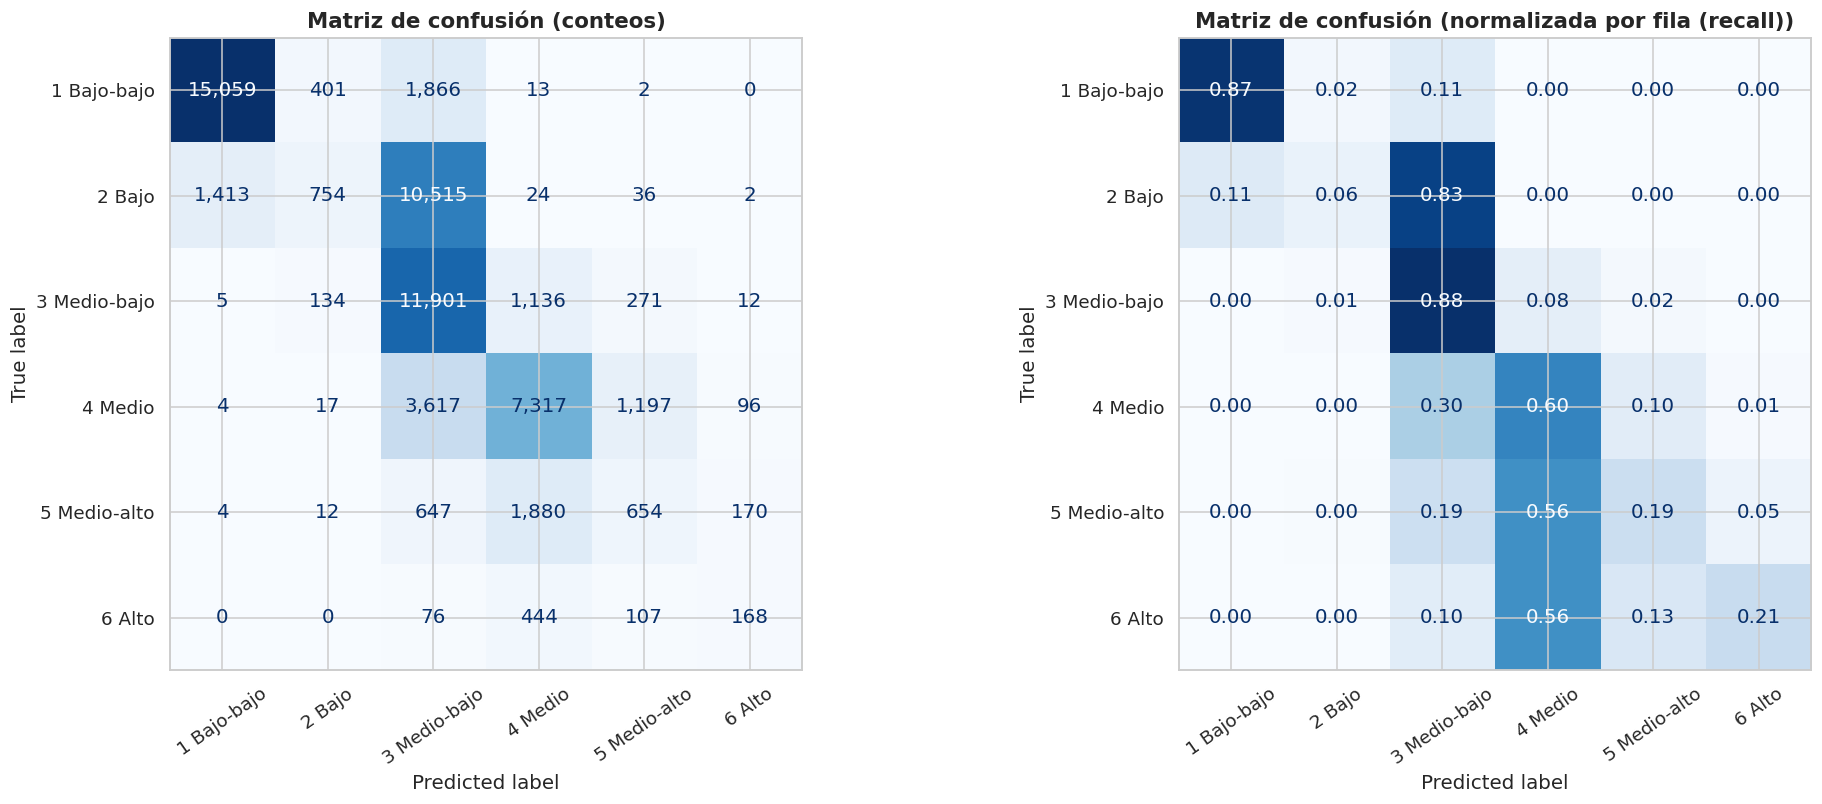

In [14]:
# Matriz de confusión del modelo principal en test, en conteos y normalizada por
# fila. La normalizada muestra el recall de cada estrato y hacia qué estratos se
# desplazan los errores (si caen en clases adyacentes, el error es "ordinal leve").
etiquetas = [C.NOMBRES_CLASES[c] for c in C.CLASES]
fig, axes = plt.subplots(1, 2, figsize=(19, 7.5))
# normalize="true" divide cada fila por su total real: la diagonal es el recall.
for ax, norm, t in [(axes[0], None, "conteos"), (axes[1], "true", "normalizada por fila (recall)")]:
    # labels=C.CLASES fija las 6 filas/columnas aunque alguna clase falte en test.
    ConfusionMatrixDisplay(confusion_matrix(y_te, pred[PRINCIPAL], labels=C.CLASES, normalize=norm),
                           display_labels=etiquetas).plot(ax=ax, cmap="Blues", colorbar=False,
                                                          values_format=".2f" if norm else ",d")
    ax.set_title(f"Matriz de confusión ({t})")
    ax.tick_params(axis="x", rotation=35)
fig.tight_layout()
G.guardar(fig, "10_confusion")
plt.show()

In [15]:
# Precisión, recall, F1 y soporte por estrato en test. Complementa el F1 macro: dice
# qué clases concretas arrastran el promedio (p. ej. estratos intermedios o raros).
# zero_division=0 evita avisos si una clase nunca se predice o no aparece en test.
print(classification_report(y_te, pred[PRINCIPAL], labels=C.CLASES, target_names=etiquetas, digits=3,
                            zero_division=0))

              precision    recall  f1-score   support

 1 Bajo-bajo      0.913     0.868     0.890     17341
      2 Bajo      0.572     0.059     0.107     12744
3 Medio-bajo      0.416     0.884     0.566     13459
     4 Medio      0.677     0.597     0.635     12248
5 Medio-alto      0.288     0.194     0.232      3367
      6 Alto      0.375     0.211     0.270       795

    accuracy                          0.598     59954
   macro avg      0.540     0.469     0.450     59954
weighted avg      0.639     0.598     0.554     59954



### Curvas ROC y precisión-recall (one-vs-rest)

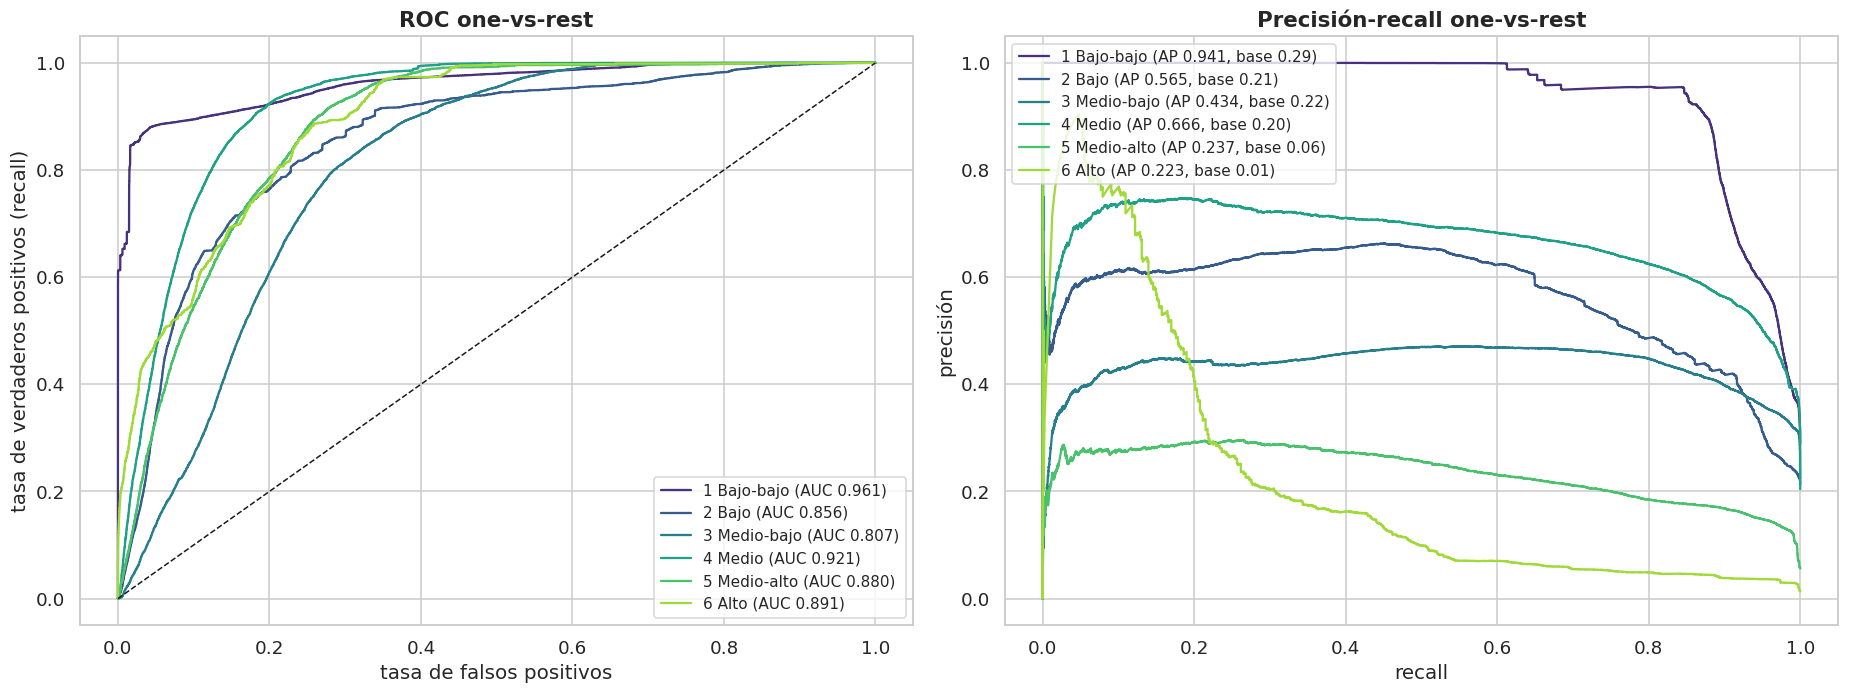

In [16]:
# Curvas ROC y precisión-recall one-vs-rest: cada estrato contra el resto, usando la
# probabilidad predicha de esa clase. Evalúan la capacidad de ORDENAR (ranking) de
# las probabilidades, independiente del umbral implícito de predict (argmax).
fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
# La columna k de predict_proba corresponde a C.CLASES[k] porque las 6 clases están
# en train y sklearn las ordena igual (classes_ = [1, ..., 6]).
for k, c in enumerate(C.CLASES):
    # Etiqueta binaria "es estrato c" frente a "no lo es".
    yb = (y_te == c).astype(int)
    # Sin positivos en test la curva no está definida: se omite esa clase.
    if yb.sum() == 0:
        continue
    fpr, tpr, _ = roc_curve(yb, proba[PRINCIPAL][:, k])
    axes[0].plot(fpr, tpr, color=G.PALETA_ESTRATO[c], label=f"{C.NOMBRES_CLASES[c]} (AUC {auc(fpr, tpr):.3f})")
    pr_, rc_, _ = precision_recall_curve(yb, proba[PRINCIPAL][:, k])
    # AP (average precision) resume la curva PR; su referencia "al azar" es la
    # prevalencia de la clase (base), no 0.5 como en ROC. Por eso se imprimen ambas.
    axes[1].plot(rc_, pr_, color=G.PALETA_ESTRATO[c],
                 label=f"{C.NOMBRES_CLASES[c]} (AP {average_precision_score(yb, proba[PRINCIPAL][:, k]):.3f}, "
                       f"base {yb.mean():.2f})")
# Diagonal = clasificador aleatorio (AUC 0.5).
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_xlabel("tasa de falsos positivos")
axes[0].set_ylabel("tasa de verdaderos positivos (recall)")
axes[0].set_title("ROC one-vs-rest")
axes[0].legend(fontsize=10)
axes[1].set_xlabel("recall")
axes[1].set_ylabel("precisión")
axes[1].set_title("Precisión-recall one-vs-rest")
axes[1].legend(fontsize=10)
fig.tight_layout()
G.guardar(fig, "10_roc_pr")
plt.show()

```{admonition} Cómo leer ROC vs. PR con desbalance
:class: note
El AUC-ROC de una clase rara puede verse alto aunque el modelo la prediga
mal, porque la tasa de falsos positivos se diluye entre muchos negativos. La
curva **precisión-recall** es más exigente: su referencia es la proporción
de la clase ("base"), no 0.5. Para los estratos 5 y 6 (minoritarios) la PR
es la curva a mirar.

**Con los datos reales (modelo B):** el AUC por estrato va de 0.81 (estrato
3, el de ordenamiento más débil) a 0.96 (estrato 1, con AP 0.94). Los
estratos 5 y 6 tienen AUC de 0.88 y 0.89, pero su precisión promedio (AP)
es de solo 0.24 y 0.22, frente a prevalencias de 0.06 y 0.01: ordenan bien,
pero no alcanzan para decidir con confianza. El caso llamativo es el
**estrato 2**: AUC 0.86 y AP 0.57 (base 0.21), es decir, sus probabilidades
lo ordenan razonablemente, y sin embargo su recall con la regla del
argmax es de solo 0.06 (reporte por clase). El problema del estrato 2 no
es de ordenamiento sino de **umbral y calibración**: su probabilidad queda
casi siempre por debajo de la del estrato 3 (ver calibración).
```

### Calibración

¿Las probabilidades significan lo que dicen? Curvas de fiabilidad
one-vs-rest por clase (10 bins por cuantiles) y error de calibración
esperado (ECE) de la clase predicha.

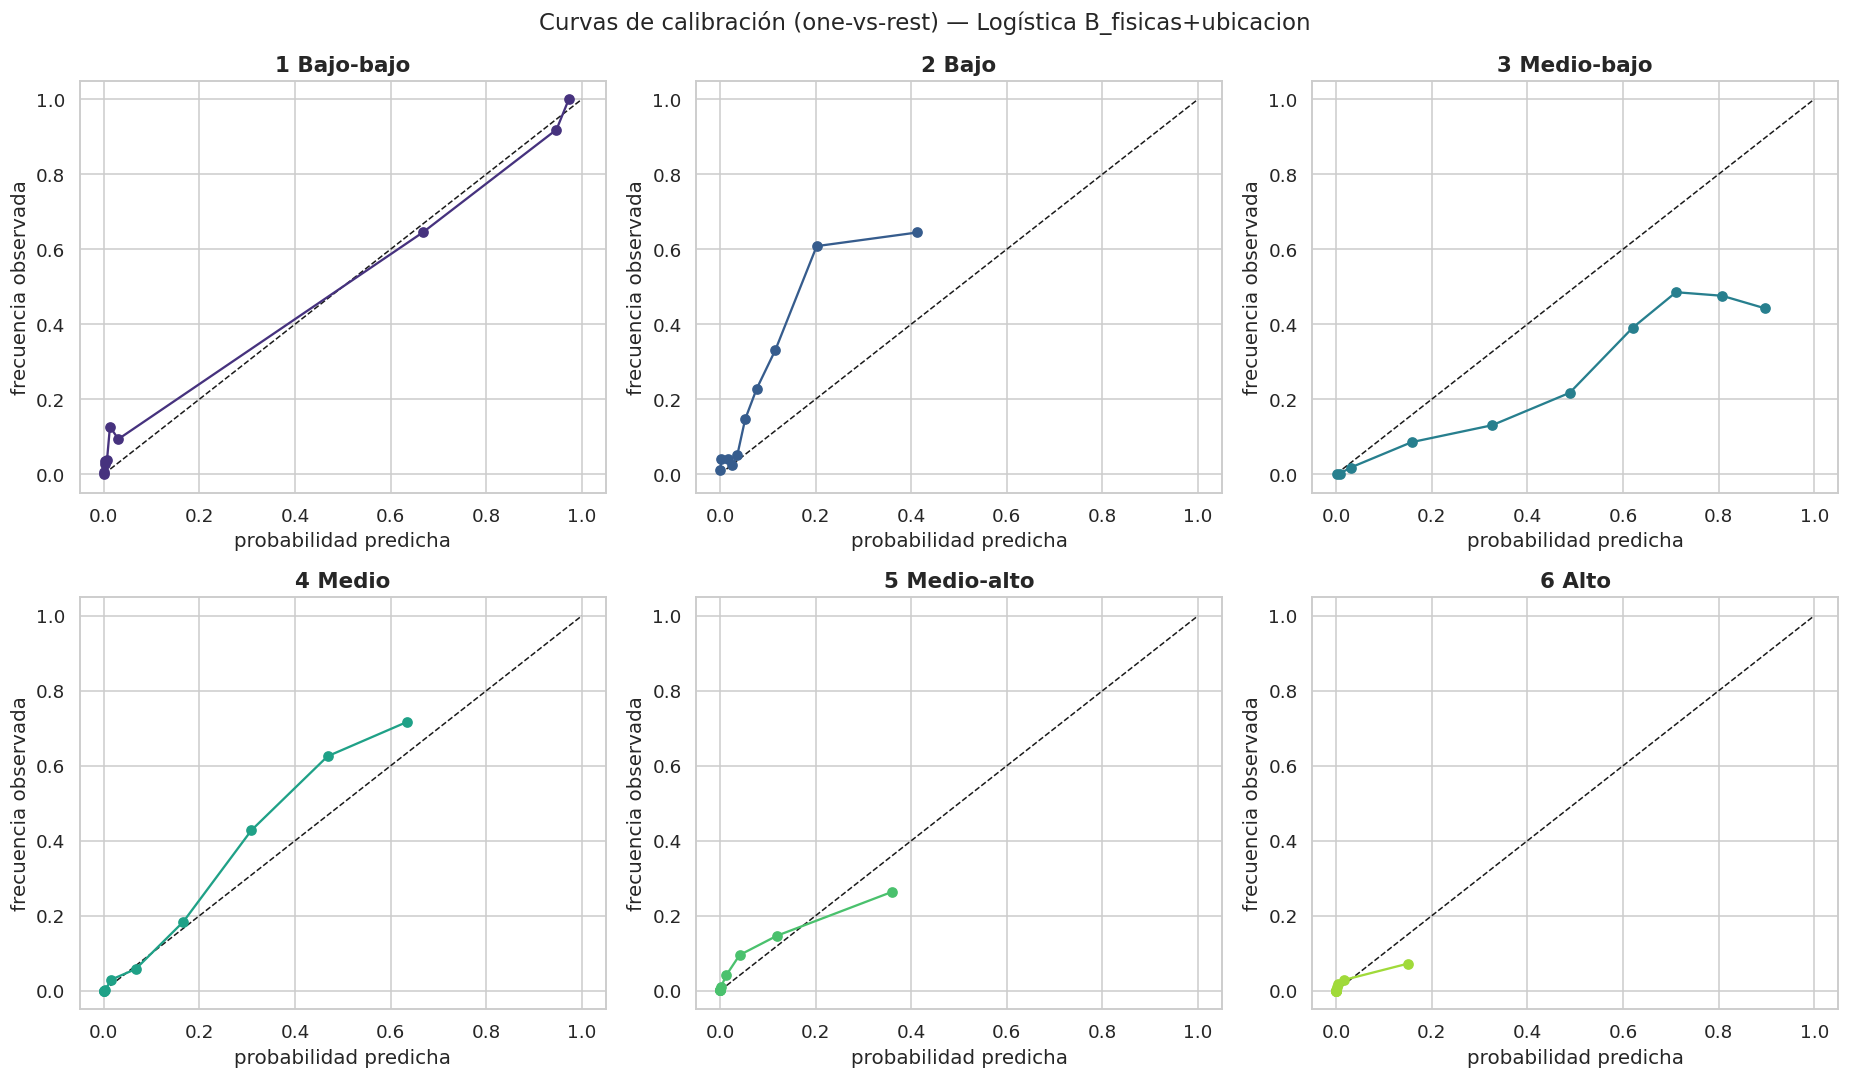

ECE (clase predicha, 10 bins): 0.1395 | Brier multiclase: 0.5479


In [17]:
# Calibración: ¿cuando el modelo dice "70 % de ser estrato c", lo es ~70 % de las
# veces? Curvas de fiabilidad one-vs-rest por estrato y ECE de la clase predicha.
# Importa porque class_weight="balanced" (si se elige) altera las probabilidades a
# propósito, y porque el cambio de dominio espacial puede desplazarlas.
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
# Un panel por estrato (2 x 3 = 6 clases).
for ax, (k, c) in zip(axes.ravel(), enumerate(C.CLASES)):
    yb = (y_te == c).astype(int)
    if yb.sum() == 0:
        ax.axis("off")
        continue
    # strategy="quantile": bins con el mismo número de unidades, así ningún punto de
    # la curva se apoya en muy pocas observaciones (las probabilidades de las clases
    # raras se concentran cerca de 0 y bins uniformes quedarían casi vacíos).
    # Devuelve (frecuencia observada, probabilidad media predicha) por bin.
    fr, mp = calibration_curve(yb, proba[PRINCIPAL][:, k], n_bins=10, strategy="quantile")
    # Diagonal = calibración perfecta; por debajo = el modelo sobreestima la clase.
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.plot(mp, fr, "o-", color=G.PALETA_ESTRATO[c])
    ax.set_title(C.NOMBRES_CLASES[c])
    ax.set_xlabel("probabilidad predicha")
    ax.set_ylabel("frecuencia observada")
fig.suptitle(f"Curvas de calibración (one-vs-rest) — {PRINCIPAL}")
fig.tight_layout()
G.guardar(fig, "10_calibracion")
plt.show()
# ECE (expected calibration error) de la clase predicha: se agrupan las unidades por
# su confianza (probabilidad máxima) y en cada grupo se compara la tasa de acierto
# con la confianza media. ECE = sum_b (n_b / n) * |acierto_b − confianza_b|.
conf = proba[PRINCIPAL].max(1)
acierto = (pred[PRINCIPAL] == y_te).astype(float)
# Bordes en los deciles de la confianza (bins de igual tamaño); np.unique elimina
# bordes repetidos si muchas unidades comparten el mismo valor.
bins = np.unique(np.quantile(conf, np.linspace(0, 1, 11)))
# Solo los bordes interiores: digitize asigna el índice de bin 0..(nbins−1), con el
# mínimo y el máximo incluidos en el primer y el último bin.
ids = np.digitize(conf, bins[1:-1])
# (ids == b).mean() es el peso n_b / n de cada bin.
ece = sum(np.abs(acierto[ids == b].mean() - conf[ids == b].mean()) * (ids == b).mean()
          for b in np.unique(ids))
# El Brier multiclase (media de sum_k (p_k − 1[y=k])^2) combina calibración y
# discriminación; se imprime junto al ECE como segunda medida de las probabilidades.
print(f"ECE (clase predicha, 10 bins): {ece:.4f} | Brier multiclase: {resultados.loc[PRINCIPAL, 'brier_multiclase']:.4f}")

## 10.5 Diagnóstico de residuos: ¿queda estructura espacial?

Para una variable ordinal se define el residuo como
$r_i = y_i - \hat{E}[y_i] = y_i - \sum_k k\,\hat p_{ik}$ (estrato observado
menos estrato esperado según las probabilidades del modelo). Si los residuos
están autocorrelacionados en el espacio, el modelo deja sin capturar
información estructural (el entorno). Se calcula Moran's I de los residuos a
nivel de edificio en test.

In [18]:
# Diagnóstico de residuos: Moran's I global de los residuos ordinales en test, para
# las dos logísticas. Si I > 0 y es significativo, los errores se agrupan en el
# espacio y al modelo le falta información del entorno (supuesto de independencia
# de los errores violado).
filas = []
res_mapa = None
for nombre in [f"Logística {k}" for k in busquedas]:
    # Estrato esperado E[y] = sum_k k * p_k: producto de la matriz de probabilidades
    # (n x 6) por el vector de clases [1..6]. Usa toda la distribución predicha, no
    # solo el argmax, así que el residuo es continuo y respeta el orden del estrato.
    esperado = proba[nombre] @ np.asarray(C.CLASES, float)
    # Residuo = y − E[y]: positivo si el modelo subestima, negativo si sobreestima.
    t = test.assign(residuo=y_te - esperado)
    # Una fila por edificio (residuo promedio): las unidades de un mismo edificio
    # comparten coordenada y casi siempre estrato, e inflarían artificialmente I.
    e = S.deduplicar_por_edificio(t[["npn_edificio", "x_km", "y_km", "residuo"]])
    # Matriz de pesos W de k vecinos más cercanos, estandarizada por filas: kNN y no
    # banda fija porque la densidad de edificios es muy desigual en la ciudad.
    Wt, _, _ = S.pesos_knn(e[["x_km", "y_km"]].to_numpy(), k=C.K_VECINOS)
    # I = (n / S0) * z'Wz / z'z con z centrado; p-valor por permutación (499 veces se
    # barajan los residuos entre edificios para obtener la distribución bajo H0 de
    # ausencia de autocorrelación), sin suponer normalidad.
    r = S.moran_global(e["residuo"].to_numpy(), Wt, n_perm=499, seed=C.SEED)
    # El residuo medio (a nivel de unidad) indica sesgo global: < 0 = sobreestima.
    filas.append({"modelo": nombre, "Moran I residuos": r["I"], "p (perm.)": r["p_perm"], "edificios": r["n"],
                  "residuo medio": t["residuo"].mean()})
    # Se guardan los residuos por edificio del modelo principal para el mapa.
    if nombre == PRINCIPAL:
        res_mapa = e
pd.DataFrame(filas).set_index("modelo")

,Moran I residuos,p (perm.),edificios,residuo medio
modelo,,,,
Logística A_fisicas,0.3350,0.0020,27239,-0.2641
Logística B_fisicas+ubicacion,0.6997,0.0020,27239,-0.1370


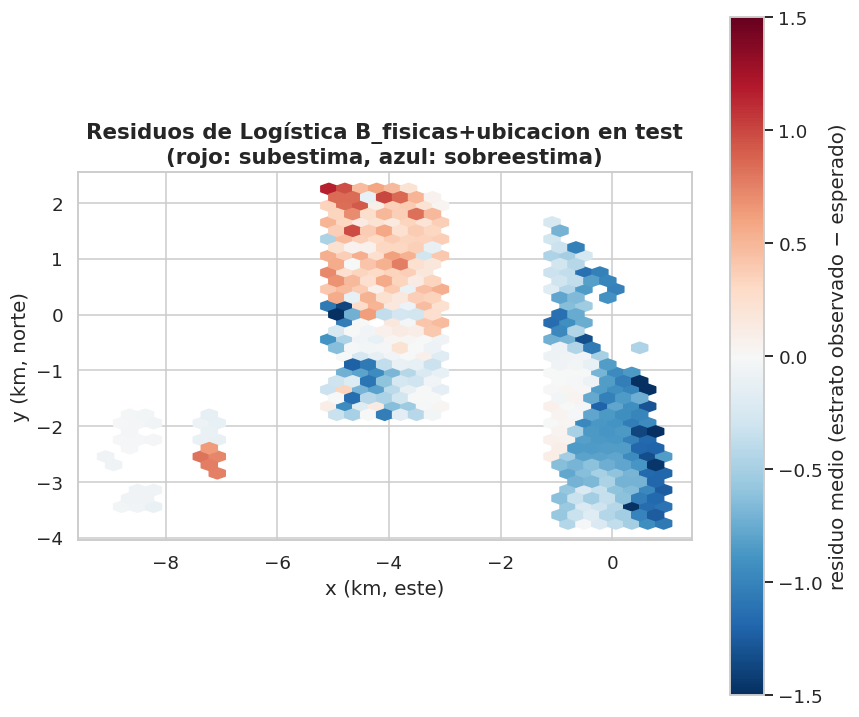

In [19]:
# Mapa de residuos del modelo principal: hexágonos con el residuo medio de los
# edificios que contienen. Muestra DÓNDE se agrupan los errores que Moran detecta.
fig, ax = plt.subplots(figsize=(9, 8))
# Escala divergente simétrica (±1.5 estratos) centrada en 0; mincnt=3 oculta
# hexágonos con menos de 3 edificios, cuyo promedio sería demasiado ruidoso.
hb = ax.hexbin(res_mapa["x_km"], res_mapa["y_km"], C=res_mapa["residuo"], reduce_C_function=np.mean,
               gridsize=35, cmap="RdBu_r", vmin=-1.5, vmax=1.5, mincnt=3)
plt.colorbar(hb, label="residuo medio (estrato observado − esperado)")
G.ejes_mapa(ax, f"Residuos de {PRINCIPAL} en test\n(rojo: subestima, azul: sobreestima)")
G.guardar(fig, "10_residuos_mapa")
plt.show()

```{admonition} Interpretación
:class: note
- **Los errores se agrupan por zonas**: Moran's I de los residuos = **0.70**
  en el modelo principal B y **0.34** en el A (ambos con p = 0.002, sobre
  27 239 edificios de test). Hay barrios enteros que el modelo sobreestima o
  subestima: el estrato depende del **entorno** (vías, espacio público,
  servicios, historia del barrio) que las variables de la vivienda no
  describen.
- Que B tenga **más** autocorrelación residual que A no significa que la
  ubicación empeore el modelo (B tiene menor sesgo medio y mejores métricas
  ordinales en test). A predice unidad por unidad con variables
  físicas "ruidosas", y ese ruido diluye el patrón espacial de sus
  residuos. B suaviza sus predicciones con la tendencia norte-sur, y lo que
  queda como residuo son justamente las **desviaciones locales** respecto a
  esa tendencia, que son muy espaciales. La tendencia lineal capta la gran
  escala, pero no los barrios.
- **Sesgo:** el residuo medio es **−0.14 estratos** en B (sobreestima
  levemente en promedio) y −0.26 en A, cuyo `class_weight="balanced"` sube
  la probabilidad de las clases altas (minoritarias en train) y contribuye
  a una sobreestimación mayor. En el mapa de B se ven tres patrones: (i) el
  bloque central del test (x ≈ −5 a −3 km) se parte en dos, con su mitad
  norte (y > 0 km) **subestimada** (rojo, hasta ≈ +1 estrato en el borde
  norte) y su mitad sur (y < −0.5 km) mayormente **sobreestimada** (azul):
  dentro de esa zona el estrato cambia más rápido de lo que permite la
  tendencia lineal; (ii) la franja oriental (x ≈ −1 a 1 km) está casi toda
  **sobreestimada**, con la sobreestimación más fuerte (azul oscuro, hasta
  −1.5 estratos) en su borde este, entre y ≈ −1 y −3.5 km; y (iii) el grupo
  aislado del suroccidente (x ≈ −9 a −7 km) queda cerca de 0, salvo un
  pequeño núcleo subestimado hacia x ≈ −7 km, y ≈ −2.5 km. La
  sobreestimación dominante es coherente con la matriz de confusión: el
  83 % del estrato 2 se predice como 3.
- Mejoras (entregable 2): rezagos espaciales de variables **físicas**
  (nunca del objetivo), interacciones o modelos no lineales (árboles,
  boosting) y variables del entorno.
```

## 10.6 Interpretación de coeficientes

En la logística multinomial hay un vector de coeficientes por clase. Como
las numéricas están estandarizadas, cada coeficiente es el cambio en el
log-odds por **una desviación estándar**. Para una lectura directa se
muestra $\beta_{6} - \beta_{1}$: el cambio en el log-odds de ser estrato 6
frente a estrato 1 por cada desviación estándar (o por pertenecer a la
categoría, en las one-hot).

Cautelas de lectura: (i) en las variables con log1p, "una DE" es una DE del
valor winsorizado y transformado; (ii) `x_km`, `y_km` y `dist_centro_km`
están relacionadas (la distancia es función de x e y), así que sus
coeficientes no se interpretan por separado sino como una tendencia espacial
conjunta; (iii) con variables categóricas redundantes (uso / condición /
tipo de vivienda) el peso se reparte entre ellas.

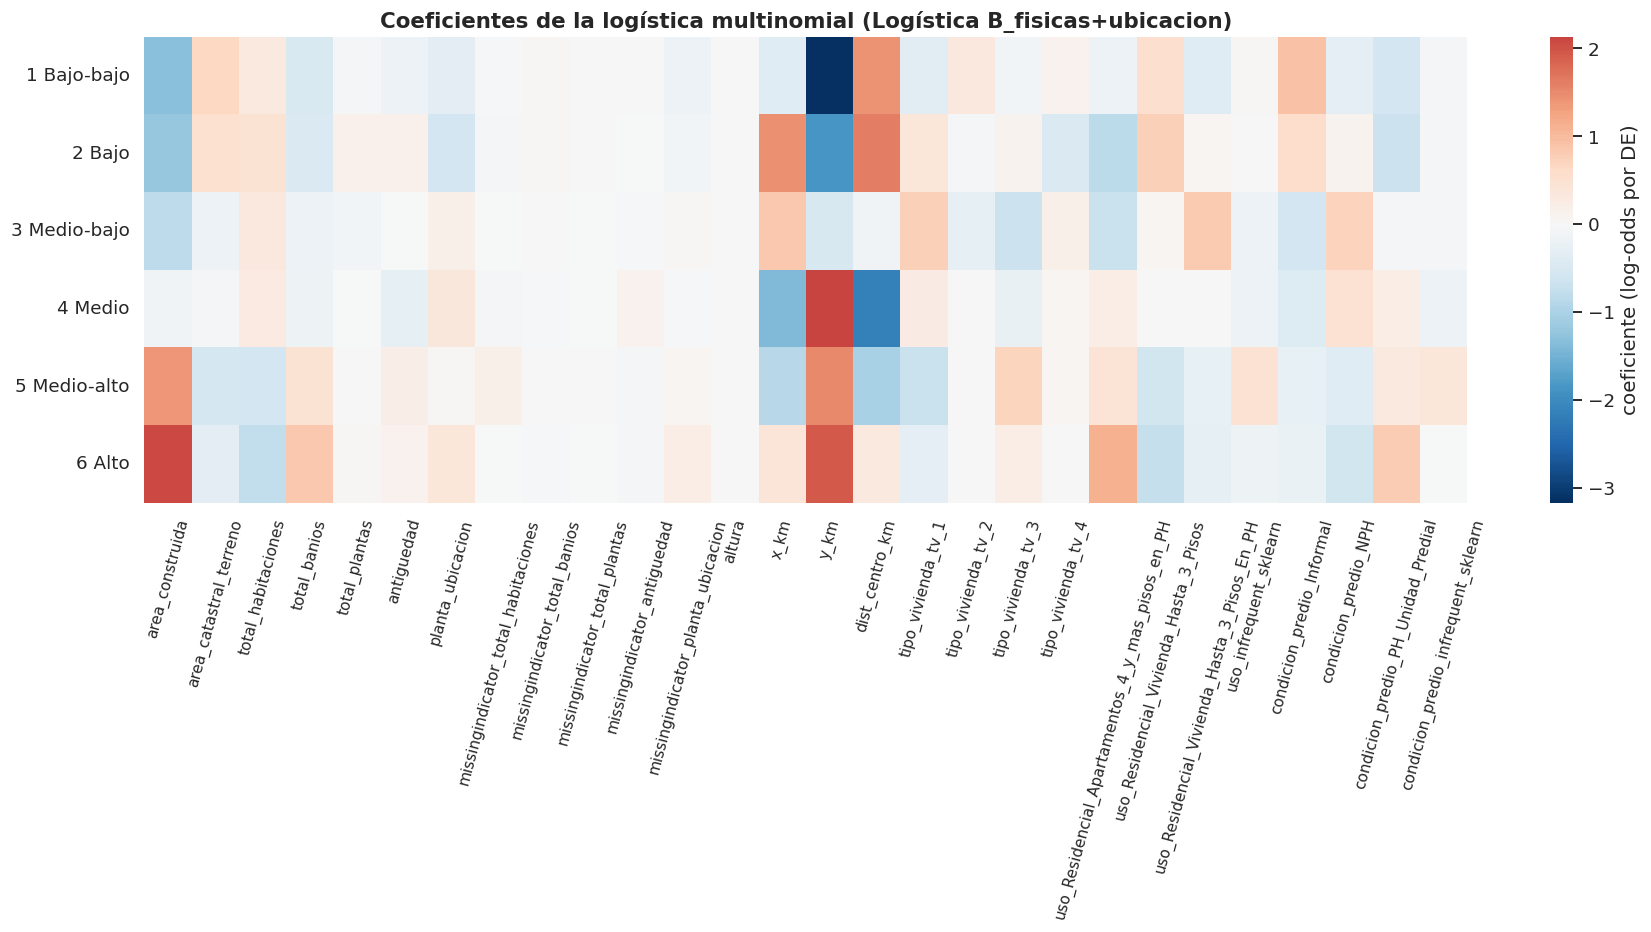

,β6 − β1,odds ratio (6 vs 1)
y_km,5.1081,165
area_construida,3.3963,29.9
total_banios,1.3649,3.92
condicion_predio_PH_Unidad_Predial,1.3613,3.9
uso_Residencial_Apartamentos_4_y_mas_pisos_en_PH,1.3123,3.71
uso_Residencial_Vivienda_Hasta_3_Pisos,-1.2862,0.276
condicion_predio_Informal,-1.1431,0.319
dist_centro_km,-1.1204,0.326
total_habitaciones,-1.0614,0.346
area_catastral_terreno,-0.9798,0.375


In [20]:
# Coeficientes del modelo principal (entrenado en todo train): mapa de calor de la
# matriz clase x variable y tabla de β6 − β1, el contraste entre los extremos de la
# escala, que resume qué empuja hacia estratos altos o bajos.
clf = finales[PRINCIPAL].named_steps["clf"]
# Nombres de las columnas DESPUÉS del preprocesamiento (incluye indicadores de
# faltante y columnas one-hot), en el mismo orden que las columnas de coef_.
nombres = finales[PRINCIPAL].named_steps["prep"].get_feature_names_out()
# Se quita el prefijo del transformador ("num_log__", "num_lin__", "cat__").
nombres = [n.split("__", 1)[1] for n in nombres]
# coef_ tiene forma (6 clases, p variables): en la multinomial hay un vector de
# coeficientes por clase (identificable solo en diferencias entre clases).
coef = pd.DataFrame(clf.coef_, index=[C.NOMBRES_CLASES[c] for c in clf.classes_], columns=nombres)
# Ancho proporcional al número de variables, con tope para que la figura quepa.
fig, ax = plt.subplots(figsize=(min(24, 0.55 * len(nombres) + 4), 5.5))
sns.heatmap(coef, cmap="RdBu_r", center=0, ax=ax, cbar_kws={"label": "coeficiente (log-odds por DE)"})
ax.set_title(f"Coeficientes de la logística multinomial ({PRINCIPAL})")
ax.tick_params(axis="x", rotation=75, labelsize=10)
G.guardar(fig, "10_coeficientes")
plt.show()
# En la multinomial solo las DIFERENCIAS entre vectores de clase tienen
# interpretación: β6 − β1 es el cambio en log(P(6)/P(1)) por una DE de la variable
# (o por pertenecer a la categoría). Última fila = estrato 6, primera = estrato 1.
lectura = pd.DataFrame({"β6 − β1": coef.iloc[-1] - coef.iloc[0]})
# Odds ratio = exp(β6 − β1). Se recorta a [−50, 50] antes de exp para evitar
# desbordamiento numérico (exp(710) ya es inf) si algún coeficiente fuera enorme;
# con ese rango el OR sigue siendo claramente "extremo". Formato de 3 cifras.
lectura["odds ratio (6 vs 1)"] = np.exp(lectura["β6 − β1"].clip(-50, 50)).map(lambda v: f"{v:.3g}")
# Las 15 variables con mayor |β6 − β1|, sin importar el signo.
lectura.sort_values("β6 − β1", key=np.abs, ascending=False).head(15)

Importancia por permutación (caída de F1 macro al desordenar cada variable
original, 3 repeticiones). Para no tocar el conjunto de prueba se calcula en
el primer fold de la CV espacial: se entrena en su parte de entrenamiento y
se permuta en su validación (submuestra de 20 000).

In [21]:
# Importancia por permutación sobre las variables ORIGINALES (antes del one-hot):
# cuánto cae el F1 macro al desordenar cada una. Se calcula en un fold de la CV
# espacial y no en test, para no volver a usar test después de la evaluación final.
from sklearn.base import clone
# Primer fold: índices de entrenamiento (ya sin el buffer) y de validación.
itr, iva = folds[0]
# clone crea una copia sin ajustar con los mismos hiperparámetros; se entrena solo
# con el train del fold para que la validación sea de zonas no vistas.
modelo_fold = clone(mejor).fit(train.iloc[itr][cols_b], y_tr[itr])
# Submuestra de hasta 20 000 unidades de validación (sin reemplazo, semilla fija)
# para acotar el costo: cada variable se re-predice n_repeats veces.
sub = np.random.default_rng(C.SEED).choice(iva, min(20_000, len(iva)), replace=False)
# Se permuta cada columna de entrada del Pipeline (una categórica se permuta
# completa, no por columna one-hot). Una caída negativa significa que la variable
# perjudica al generalizar a la zona de validación.
pi = permutation_importance(modelo_fold, train.iloc[sub][cols_b], y_tr[sub], scoring="f1_macro",
                            n_repeats=3, random_state=C.SEED, n_jobs=-1)
# Media y desviación de la caída entre las 3 repeticiones, ordenadas de mayor a menor.
imp = pd.DataFrame({"caída F1 macro": pi.importances_mean, "desv.": pi.importances_std},
                   index=cols_b).sort_values("caída F1 macro", ascending=False)
imp

,caída F1 macro,desv.
dist_centro_km,0.1275,0.0011
x_km,0.1181,0.0007
y_km,0.0991,0.0007
condicion_predio,0.0517,0.0001
area_construida,0.0516,0.0006
uso,0.0505,0.0006
area_catastral_terreno,0.0441,0.0015
planta_ubicacion,0.0218,0.0032
total_habitaciones,0.0202,0.0007
total_banios,0.0161,0.0025


## 10.7 Resumen de resultados

In [22]:
# Resumen reproducible: se guardan en resultados_modelo.json las tablas clave (CV,
# test, IC, comparaciones, optimismo e hiperparámetros) para que el informe y los
# capítulos siguientes lean los números de un archivo y no se copien a mano.
salida = {
    "tabla_cv": tabla_cv.round(4).to_dict(),
    "resultados_test": resultados.round(4).to_dict(),
    "ic_modelo_principal": ic.round(4).to_dict(),
    # astype(str): la columna booleana "¿IC excluye 0?" (numpy.bool_) no es
    # serializable directamente por json.
    "comparaciones_f1": comp.round(4).astype(str).to_dict(),
    "optimismo_validacion_aleatoria": optimismo.round(4).to_dict(),
    # str() para que None y los floats de la rejilla se guarden sin problemas.
    "mejores_hiperparametros": {k: {kk: str(vv) for kk, vv in v.best_params_.items()} for k, v in busquedas.items()},
    "n_train_final": int(len(train)), "n_test": int(len(test)), "buffer_km": buffer_km,
}
(C.CARPETA_PROCESADOS / "resultados_modelo.json").write_text(json.dumps(salida, indent=2, ensure_ascii=False),
                                                              encoding="utf-8")
# Tabla final compacta: métricas de clasificación, de ranking (AUC) y ordinales de
# todos los modelos en test, para leer de un vistazo la comparación con las bases.
resultados.loc[:, ["accuracy", "balanced_accuracy", "f1_macro", "AUC_OvR_macro", "MAE_ordinal", "accuracy_±1",
                   "kappa_cuadrático"]]

,accuracy,balanced_accuracy,f1_macro,AUC_OvR_macro,MAE_ordinal,accuracy_±1,kappa_cuadrático
Dummy (mayoritaria),0.2892,0.1667,0.0748,0.5000,1.5654,0.5018,0.0000
Dummy (estratificada),0.2251,0.1703,0.1667,0.5021,1.5007,0.5543,0.0066
Dummy (uniforme),0.1650,0.1648,0.1458,0.5000,1.8977,0.4479,-0.0014
Moda por zona,0.4807,0.3748,0.3280,0.6636,0.9363,0.7471,0.4296
Logística A_fisicas,0.4203,0.4112,0.3490,0.7965,0.8182,0.8027,0.6546
Logística B_fisicas+ubicacion,0.5980,0.4691,0.4500,0.8860,0.4637,0.9411,0.8137


```{admonition} Interpretación de los resultados
:class: important
**1. ¿Supera a las líneas base?** A las triviales, con claridad; a la
espacial, en todas las métricas, pero en F1 macro sin significancia
estadística. El modelo principal (B: variables físicas + ubicación;
C = 0.01, sin pesos de clase) logra en test **F1 macro 0.450**, balanced
accuracy 0.469, AUC OvR 0.886 y accuracy 0.598, frente a 0.075 de F1 de la
Dummy mayoritaria (Δ = +0.375, IC 95 % [0.11, 0.39], p = 0.002) y 0.167 de
la estratificada (Δ = +0.283, IC [0.03, 0.31], p = 0.028). Frente a la
**moda por zona de 2 km** (una regla sin variables físicas: "predice el
estrato más común de tu zona en train"; F1 0.328) la diferencia de F1 es
+0.122, pero su IC [−0.01, 0.19] incluye 0 (p = 0.124): con 7 bloques de
test no alcanza para declararla significativa. Descriptivamente, B la
supera en todo: accuracy 0.598 frente a 0.481, MAE ordinal 0.46 frente a
0.94, kappa cuadrático 0.81 frente a 0.43, accuracy ±1 0.94 frente a 0.75 y
log loss 1.03 frente a 2.58. En CV espacial ocurre lo mismo: 0.299 frente a
0.193, con desviaciones entre folds de 0.086 y 0.076.

**2. ¿Cuánto aporta la ubicación?** CV y test apuntan en la misma
dirección, con distinta fuerza. En la CV espacial la ventaja de B sobre A
es mínima (0.299 frente a 0.283, dentro del ruido). En test, B supera a A
por 0.10 de F1 (0.450 frente a 0.349), aunque esa diferencia tiene IC
[−0.05, 0.14], que incluye 0 (p = 0.31); la ventaja es más nítida en
accuracy (0.60 frente a 0.42), error ordinal (MAE 0.46 frente a 0.82;
accuracy ±1 0.94 frente a 0.80), kappa (0.81 frente a 0.65), AUC (0.89
frente a 0.80), log loss (1.03 frente a 1.35) y Brier (0.55 frente a 0.69).
La importancia por permutación (punto 7) va en la misma línea: las tres
variables de ubicación son las más importantes. Lectura prudente: las
coordenadas, como tendencia lineal, ayudan sobre todo a no equivocarse "por
mucho"; con 7 bloques de test y una CV tan variable, el tamaño de su aporte
al F1 macro no puede fijarse con precisión. Aun sin ubicación, A iguala o
supera a la moda por zona en F1 (0.349 frente a 0.328), MAE (0.82 frente a
0.94) y kappa (0.65 frente a 0.43), aunque no en accuracy (0.42 frente a
0.48).

**3. ¿Dónde se equivoca?** Según la matriz de confusión normalizada, el
modelo reconoce muy bien el estrato 1 (recall 0.87, precisión 0.91; de sus
errores, el grueso, 11 % del estrato, se predice como 3) y razonablemente el 4 (recall 0.60; el 30 % se
predice como 3 y el 10 % como 5). Los problemas son dos desplazamientos
hacia el centro de la escala: (i) **el estrato 2 casi nunca se predice**
(recall 0.06): el **83 %** de sus unidades (10 515 de 12 744) se clasifica
como 3 y el 11 % como 1. El estrato 3 funciona como clase "refugio": el
modelo lo predice para 28 622 unidades (48 % del test, cuando el 22 % es
realmente estrato 3), de ahí su recall alto (0.88) y su precisión baja
(0.42). (ii) Los estratos altos se "bajan" a 4: el **56 %** del estrato 5 y
el **56 %** del 6 se predicen como 4; el 5 acierta solo el 19 % y el 6 el
21 %. Los errores son casi siempre entre estratos adyacentes: accuracy ±1
de 0.94 (solo ≈6 % de las unidades se equivoca por dos estratos o más),
frente a 0.80 de A y 0.75 de la moda por zona. Entre los estratos 2 y 3
(26 203 unidades) el 89 % se predice como 2 o 3, pero casi todo como 3: se
separan bien de los extremos, no entre sí. En 5 y 6 la precisión es baja
(0.29 y 0.38): el AP del estrato 6 es 0.22 frente a una prevalencia de
1.3 % en test (unas 17 veces el azar), insuficiente aún para usarlo como
clasificador.

**4. ¿Confianza en las probabilidades?** Limitada: ECE = 0.14 y Brier 0.55.
Sin reponderado de clases, la distorsión no viene de `balanced` sino del
desplazamiento hacia el estrato 3: en las curvas de calibración el estrato
3 está **sobreestimado** (cuando el modelo promete 70–90 %, se observa
44–49 %) y el 2 **subestimado** (con ≈20 % prometido se observa ≈61 %, y
con ≈41 %, ≈64 %). Eso explica que el 2 pierda casi siempre el argmax frente
al 3 pese a su AUC de 0.86. El estrato 1 está bien calibrado; el 4,
ligeramente subestimado (promete ≈63 %, se observa ≈72 %); el 5,
sobreestimado en su tramo alto (promete ≈36 %, se observa ≈26 %), y el 6
nunca recibe más de ≈15 % de probabilidad (se observa ≈7 %). Si se van a
usar como probabilidades, o para ajustar umbrales por clase (lo que
podría recuperar parte del estrato 2), hay que recalibrarlas (entregable 2).

**5. ¿Queda estructura?** Sí: Moran de residuos 0.70 (B) y 0.34 (A), ambos
con p = 0.002, con errores agrupados por zonas (sección 10.5): mitad norte
del bloque central subestimada y franja oriental sobreestimada.

**6. ¿Más datos ayudarían?** Poco: en la curva de aprendizaje el F1 de
validación pasa de 0.27 a 0.29 al multiplicar por 20 los datos (de 2 703 a
54 062 unidades). El límite es el modelo lineal y la falta de variables del
entorno.

**7. Coeficientes e importancia.** En B, la señal más fuerte es la
**posición norte-sur** (`y_km`: β6−β1 = 5.1 por DE; OR 165), coherente con
el gradiente norte-sur del estrato (cap. 4.3 y 8.2); `x_km` (0.8) y
`dist_centro_km` (−1.1) completan la tendencia espacial y, por la cautela
(ii), se leen en conjunto con ella. Entre las físicas, hacia estratos altos
empujan el **área construida** (3.4; OR 30), más **baños** (1.4), ser
unidad predial en PH (1.4), apartamento en edificio PH de 4 o más pisos
(1.3) y un piso más alto (`planta_ubicacion`, 0.7). Con el área fija, **más
habitaciones** empuja hacia estratos bajos (−1.1: habitaciones más
pequeñas), igual que ser vivienda de hasta 3 pisos (−1.3), predio
`Informal` (−1.1) o tener más área de terreno (−1.0). La importancia por
permutación (fold 0 de la CV, 54 062 unidades de entrenamiento) pone
primero a las tres variables de ubicación (caídas de F1 de 0.13, 0.12 y
0.10 para distancia al centro, x e y), seguidas de `condicion_predio`, área
construida y `uso` (≈0.05 cada una) y área de terreno (0.04); planta,
habitaciones, baños y tipo de vivienda aportan 0.01–0.02, y total de
plantas, altura y antigüedad prácticamente nada (antigüedad −0.002 ± 0.004,
indistinguible de 0). Se calculó en un solo fold y debe leerse como pista,
no como resultado firme.

**8. ¿Desempeño sospechoso?** No. El accuracy (0.598) está lejos del umbral
de alerta de 0.80, la auditoría de fuga no encontró proxies (cap. 9) y la
validación respeta edificios y bloques. El accuracy ±1 (0.94) y el kappa
(0.81) son altos porque casi todos los errores son de un solo estrato, no
por fuga. La cifra más honesta del desempeño esperado en zonas nuevas es
la de la CV espacial, **F1 macro ≈ 0.30 ± 0.09**, con la advertencia de que
esa cifra depende de cómo se asignen los bloques a los folds (sección
10.2); el 0.45 de test es una realización favorable.
```